# Sheet 10

In [18]:
from jax.lax import associative_scan
from jax.random import randint, PRNGKey
import jax.numpy as jnp
import jax
import time
import os
from matplotlib import pyplot as plt

In [19]:
def cumsum_sequential(sequence):
    cumsum = jnp.zeros_like(sequence)
    cumsum = cumsum.at[0].set(sequence[0])
    for i in range(1, len(sequence)):
        cumsum = cumsum.at[i].set(cumsum[i - 1] + sequence[i])
    return cumsum

def cumsum_associative_scan(sequence):
    def associative_binary_operator(x, y):
        return x + y
    return associative_scan(associative_binary_operator, sequence)

In [20]:
lengths = [10, 100, 1000, 10000]
times_sequential = []
times_parallel = []

for length in lengths:
    sequence = randint(PRNGKey(0), (length, ), 0, 10,)

    # Sequential
    start = time.time()
    cumsum_sequential(sequence).block_until_ready()
    end = time.time()
    times_sequential.append(end - start)

    # Parallel
    start = time.time()
    cumsum_associative_scan(sequence).block_until_ready()
    end = time.time()
    times_parallel.append(end - start)


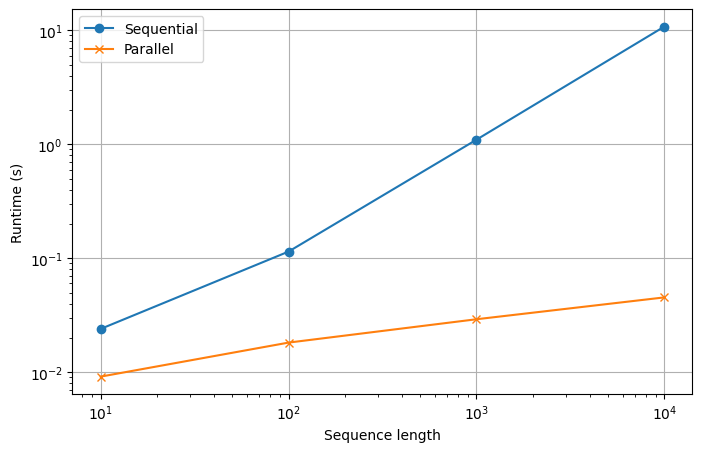

In [21]:
# Plot
plt.figure(figsize=(8, 5))
plt.plot(lengths, times_sequential, label='Sequential', marker='o')
plt.plot(lengths, times_parallel, label='Parallel', marker='x')
plt.xlabel('Sequence length')
plt.ylabel('Runtime (s)')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.show()